# Link Prediction: Сравнительный анализ методов на графах Cora и Congress

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import math
import time
import json
import itertools
import random
from collections import defaultdict
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.sparse import csr_matrix, eye, lil_matrix
from scipy.sparse.linalg import inv as sp_inv, eigsh
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected
from dgl.nn import DeepWalk, GraphConv, SAGEConv
from torch.optim import SparseAdam, Adam
from torch.utils.data import DataLoader
from node2vec import Node2Vec
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
device = torch.device('cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"DGL version: {dgl.__version__}")

Using device: cpu
PyTorch version: 2.8.0+cu129
DGL version: 2.0.0


## 1. Вспомогательные функции

In [2]:
def compute_auc_ap(scores_pos, scores_neg):
    y_true = [1] * len(scores_pos) + [0] * len(scores_neg)
    y_pred = scores_pos + scores_neg
    auc = roc_auc_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    return auc, ap

def sample_negative_edges(pos_edges, num_nodes, num_neg_per_pos=1, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    pos_set = set(pos_edges)
    neg_edges = []
    for u, v in pos_edges:
        for _ in range(num_neg_per_pos):
            while True:
                u_neg = np.random.randint(0, num_nodes)
                v_neg = np.random.randint(0, num_nodes)
                if u_neg != v_neg and (u_neg, v_neg) not in pos_set:
                    neg_edges.append((u_neg, v_neg))
                    break
    return neg_edges

def train_val_test_split(edge_set, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    random.seed(seed)
    edges_list = list(edge_set)
    random.shuffle(edges_list)
    n = len(edges_list)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_edges = edges_list[:train_end]
    val_edges = edges_list[train_end:val_end]
    test_edges = edges_list[val_end:]
    return train_edges, val_edges, test_edges

## 2. Загрузка датасета Cora (неориентированный)

In [3]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

edge_index = to_undirected(data.edge_index).numpy()
src_cora = edge_index[0]
dst_cora = edge_index[1]
edge_set_cora_full = set(zip(src_cora, dst_cora))

print(f"Cora: |V| = {data.num_nodes}, |E| (undirected) = {len(edge_set_cora_full)}")
print(f"Node features dimension: {data.x.shape[1]}")

Cora: |V| = 2708, |E| (undirected) = 10556
Node features dimension: 1433


## 3. Загрузка датасета Congress (ориентированный)

In [4]:
with open('congress_data/congress_network/congress_network_data.json', 'r') as f:
    congress_raw = json.load(f)[0]

G_cong = nx.DiGraph()
n_nodes_cong = len(congress_raw['usernameList'])
for i in range(n_nodes_cong):
    G_cong.add_node(i)
for i in range(n_nodes_cong):
    for j, w in zip(congress_raw['outList'][i], congress_raw['outWeight'][i]):
        G_cong.add_edge(i, j, weight=w)

src_cong = np.array([u for u, v in G_cong.edges()])
dst_cong = np.array([v for u, v in G_cong.edges()])
edge_set_cong_full = set(zip(src_cong, dst_cong))

print(f"Congress: |V| = {G_cong.number_of_nodes()}, |E| = {G_cong.number_of_edges()}")
print(f"Graph is directed: {any((v,u) not in edge_set_cong_full for u,v in list(edge_set_cong_full)[:100])}")

Congress: |V| = 475, |E| = 13289
Graph is directed: True


## 4. Разбиение данных и построение обучающих структур

In [5]:
pos_train_cora, pos_val_cora, pos_test_cora = train_val_test_split(edge_set_cora_full)
neg_train_cora = sample_negative_edges(pos_train_cora, data.num_nodes, num_neg_per_pos=1)
neg_val_cora = sample_negative_edges(pos_val_cora, data.num_nodes, num_neg_per_pos=1)
neg_test_cora = sample_negative_edges(pos_test_cora, data.num_nodes, num_neg_per_pos=1)

rows_train_cora = []
cols_train_cora = []
neighbours_train_cora = defaultdict(set)
for u, v in pos_train_cora:
    rows_train_cora.append(u)
    cols_train_cora.append(v)
    rows_train_cora.append(v)
    cols_train_cora.append(u)
    neighbours_train_cora[u].add(v)
    neighbours_train_cora[v].add(u)
A_train_cora = csr_matrix((np.ones(len(rows_train_cora)), (rows_train_cora, cols_train_cora)), 
                          shape=(data.num_nodes, data.num_nodes))

pos_train_cong, pos_val_cong, pos_test_cong = train_val_test_split(edge_set_cong_full)
neg_train_cong = sample_negative_edges(pos_train_cong, n_nodes_cong, num_neg_per_pos=1)
neg_val_cong = sample_negative_edges(pos_val_cong, n_nodes_cong, num_neg_per_pos=1)
neg_test_cong = sample_negative_edges(pos_test_cong, n_nodes_cong, num_neg_per_pos=1)

out_neighbours_train_cong = defaultdict(set)
in_neighbours_train_cong = defaultdict(set)
for u, v in pos_train_cong:
    out_neighbours_train_cong[u].add(v)
    in_neighbours_train_cong[v].add(u)

print(f"Cora: train={len(pos_train_cora)}, val={len(pos_val_cora)}, test={len(pos_test_cora)}")
print(f"Congress: train={len(pos_train_cong)}, val={len(pos_val_cong)}, test={len(pos_test_cong)}")
print(f"A_train_cora ненулевых элементов: {A_train_cora.nnz}")

Cora: train=8444, val=1056, test=1056
Congress: train=10631, val=1329, test=1329
A_train_cora ненулевых элементов: 10148


## 5. Локальные эвристики (Common Neighbors, Adamic-Adar)

In [6]:
def cn_undirected(u, v, neighbors):
    return len(neighbors[u] & neighbors[v])

def aa_undirected(u, v, neighbors):
    inter = neighbors[u] & neighbors[v]
    score = 0.0
    for z in inter:
        deg = len(neighbors[z])
        if deg > 1:
            score += 1.0 / math.log(deg)
    return score

def cn_directed(u, v, out_neighbors, in_neighbors):
    return len(out_neighbors[u] & in_neighbors[v])

def aa_directed(u, v, out_neighbors, in_neighbors):
    inter = out_neighbors[u] & in_neighbors[v]
    score = 0.0
    for z in inter:
        total_deg = len(out_neighbors[z]) + len(in_neighbors[z])
        if total_deg > 1:
            score += 1.0 / math.log(total_deg)
    return score

def evaluate_heuristic(heuristic_func, pos_edges, neg_edges, *args):
    scores_pos = [heuristic_func(u, v, *args) for u, v in pos_edges]
    scores_neg = [heuristic_func(u, v, *args) for u, v in neg_edges]
    return compute_auc_ap(scores_pos, scores_neg)

print("Cora (undirected) - эвристики на только обучающих соседях")
auc_cn_cora, ap_cn_cora = evaluate_heuristic(cn_undirected, pos_test_cora, neg_test_cora, neighbours_train_cora)
auc_aa_cora, ap_aa_cora = evaluate_heuristic(aa_undirected, pos_test_cora, neg_test_cora, neighbours_train_cora)
print(f"CN: AUC={auc_cn_cora:.4f}, AP={ap_cn_cora:.4f}")
print(f"AA: AUC={auc_aa_cora:.4f}, AP={ap_aa_cora:.4f}")

print("\nCongress (directed) - эвристики на только обучающих соседях")
auc_cn_cong, ap_cn_cong = evaluate_heuristic(cn_directed, pos_test_cong, neg_test_cong, 
                                              out_neighbours_train_cong, in_neighbours_train_cong)
auc_aa_cong, ap_aa_cong = evaluate_heuristic(aa_directed, pos_test_cong, neg_test_cong,
                                             out_neighbours_train_cong, in_neighbours_train_cong)
print(f"CN_dir: AUC={auc_cn_cong:.4f}, AP={ap_cn_cong:.4f}")
print(f"AA_dir: AUC={auc_aa_cong:.4f}, AP={ap_aa_cong:.4f}")

Cora (undirected) - эвристики на только обучающих соседях
CN: AUC=0.7452, AP=0.7403
AA: AUC=0.7463, AP=0.7448

Congress (directed) - эвристики на только обучающих соседях
CN_dir: AUC=0.8459, AP=0.8193
AA_dir: AUC=0.8489, AP=0.8359


## 6. Katz index 

=== Katz на Cora ===
λ_max = 24.2841, β_max = 0.0412

Сетка β: от 0.0010 до 0.0391
beta=0.0010: AUC=0.9705, AP=0.9719
beta=0.0030: AUC=0.9705, AP=0.9719
beta=0.0050: AUC=0.9704, AP=0.9719
beta=0.0070: AUC=0.9704, AP=0.9719
beta=0.0090: AUC=0.9704, AP=0.9720
beta=0.0110: AUC=0.9704, AP=0.9720
beta=0.0130: AUC=0.9704, AP=0.9720
beta=0.0150: AUC=0.9703, AP=0.9721
beta=0.0171: AUC=0.9703, AP=0.9722
beta=0.0191: AUC=0.9703, AP=0.9723
beta=0.0211: AUC=0.9702, AP=0.9725
beta=0.0231: AUC=0.9702, AP=0.9727
beta=0.0251: AUC=0.9701, AP=0.9737
beta=0.0271: AUC=0.9700, AP=0.9747
beta=0.0291: AUC=0.9699, AP=0.9753
beta=0.0311: AUC=0.9698, AP=0.9754
beta=0.0331: AUC=0.9696, AP=0.9754
beta=0.0351: AUC=0.9694, AP=0.9754
beta=0.0371: AUC=0.9690, AP=0.9757
beta=0.0391: AUC=0.9671, AP=0.9728

Лучший β = 0.0010, валидационный AUC = 0.9705
Тест Cora: AUC=0.9735, AP=0.9730


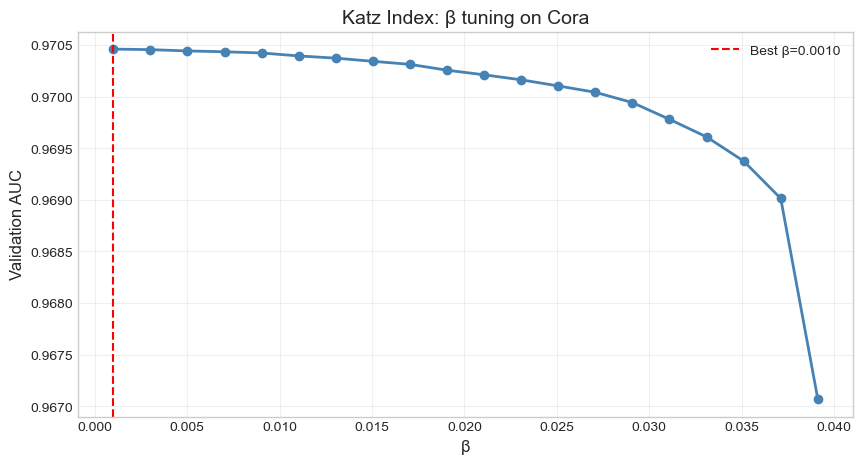


=== Katz на Congress (ориентированный) ===
Спектральный радиус ≈ 33.6900, β_max = 0.0297
Сетка β: от 0.0010 до 0.0282

Подбор β на валидации Congress:
beta=0.0010: AUC=0.8178, AP=0.7275
beta=0.0029: AUC=0.8177, AP=0.7275
beta=0.0049: AUC=0.8175, AP=0.7273
beta=0.0068: AUC=0.8172, AP=0.7271
beta=0.0088: AUC=0.8170, AP=0.7270
beta=0.0107: AUC=0.8167, AP=0.7267
beta=0.0127: AUC=0.8162, AP=0.7263
beta=0.0146: AUC=0.8157, AP=0.7258
beta=0.0165: AUC=0.8149, AP=0.7251
beta=0.0185: AUC=0.8140, AP=0.7244
beta=0.0204: AUC=0.8125, AP=0.7241
beta=0.0224: AUC=0.8103, AP=0.7253
beta=0.0243: AUC=0.8074, AP=0.7284
beta=0.0263: AUC=0.8033, AP=0.7345
beta=0.0282: AUC=0.7970, AP=0.7419

Лучший β = 0.0010, валидационный AUC = 0.8178
Тест Congress: AUC=0.8243, AP=0.7314


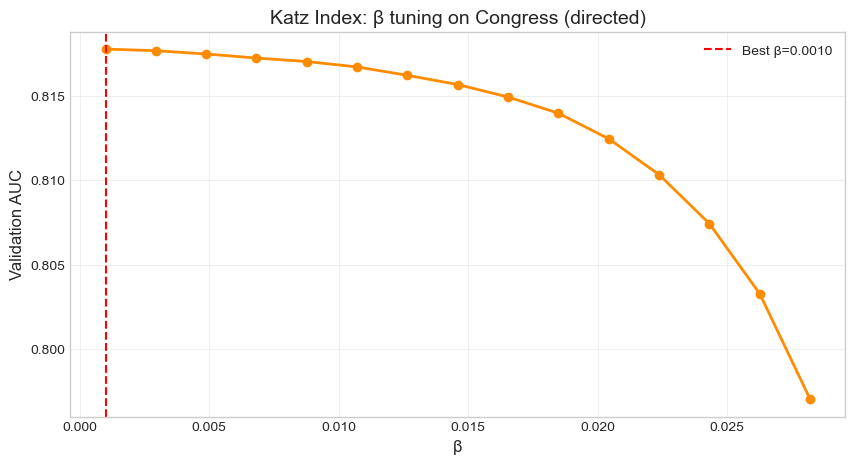

In [7]:
from scipy.sparse.linalg import inv as sp_inv, eigsh

def compute_katz_scores(A, beta, pos_edges, neg_edges):
    I = eye(A.shape[0])
    try:
        S = sp_inv(I - beta * A) - I
        scores_pos = [S[u, v] for u, v in pos_edges]
        scores_neg = [S[u, v] for u, v in neg_edges]
        return scores_pos, scores_neg
    except Exception as e:
        print(f"beta={beta:.4f} failed: {e}")
        return None, None

def tune_katz(A, betas, pos_val, neg_val):
    best_beta = None
    best_auc = 0.0
    results = []
    for beta in betas:
        scores_pos, scores_neg = compute_katz_scores(A, beta, pos_val, neg_val)
        if scores_pos is not None:
            auc, ap = compute_auc_ap(scores_pos, scores_neg)
            results.append((beta, auc, ap))
            print(f"beta={beta:.4f}: AUC={auc:.4f}, AP={ap:.4f}")
            if auc > best_auc:
                best_auc = auc
                best_beta = beta
        else:
            results.append((beta, 0.0, 0.0))
    return best_beta, best_auc, results

print("=== Katz на Cora ===")

try:
    lambda_max_cora = eigsh(A_train_cora, k=1, return_eigenvectors=False, which='LM')[0]
    beta_max_cora = 1.0 / lambda_max_cora
    print(f"λ_max = {lambda_max_cora:.4f}, β_max = {beta_max_cora:.4f}")
except Exception as e:
    print(f"Не удалось вычислить λ_max: {e}")
    beta_max_cora = 0.1

betas_cora = np.linspace(0.001, beta_max_cora * 0.95, 20)
print(f"\nСетка β: от {betas_cora[0]:.4f} до {betas_cora[-1]:.4f}")

best_beta_cora, best_val_auc_cora, katz_val_results_cora = tune_katz(A_train_cora, betas_cora, pos_val_cora, neg_val_cora)

print(f"\nЛучший β = {best_beta_cora:.4f}, валидационный AUC = {best_val_auc_cora:.4f}")

scores_pos, scores_neg = compute_katz_scores(A_train_cora, best_beta_cora, pos_test_cora, neg_test_cora)
auc_katz_cora, ap_katz_cora = compute_auc_ap(scores_pos, scores_neg)
print(f"Тест Cora: AUC={auc_katz_cora:.4f}, AP={ap_katz_cora:.4f}")

plt.figure(figsize=(10, 5))
betas_plot = [r[0] for r in katz_val_results_cora]
aucs_plot = [r[1] for r in katz_val_results_cora]
plt.plot(betas_plot, aucs_plot, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.axvline(x=best_beta_cora, color='red', linestyle='--', label=f'Best β={best_beta_cora:.4f}')
plt.xlabel('β', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Katz Index: β tuning on Cora', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('katz_tuning_cora.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Katz на Congress (ориентированный) ===")

rows_cong = [u for u, v in pos_train_cong]
cols_cong = [v for u, v in pos_train_cong]
A_train_cong = csr_matrix((np.ones(len(rows_cong)), (rows_cong, cols_cong)), 
                          shape=(n_nodes_cong, n_nodes_cong))

try:
    from scipy.sparse.linalg import svds
    sigma = svds(A_train_cong, k=1, return_singular_vectors=False)[0]
    lambda_max_cong = sigma
    beta_max_cong = 1.0 / lambda_max_cong
    print(f"Спектральный радиус ≈ {lambda_max_cong:.4f}, β_max = {beta_max_cong:.4f}")
except Exception as e:
    print(f"Не удалось вычислить спектральный радиус: {e}")
    beta_max_cong = 0.05

betas_cong = np.linspace(0.001, beta_max_cong * 0.95, 15)
print(f"Сетка β: от {betas_cong[0]:.4f} до {betas_cong[-1]:.4f}")

print("\nПодбор β на валидации Congress:")
best_beta_cong, best_val_auc_cong, katz_val_results_cong = tune_katz(A_train_cong, betas_cong, pos_val_cong, neg_val_cong)

print(f"\nЛучший β = {best_beta_cong:.4f}, валидационный AUC = {best_val_auc_cong:.4f}")

scores_pos, scores_neg = compute_katz_scores(A_train_cong, best_beta_cong, pos_test_cong, neg_test_cong)
auc_katz_cong, ap_katz_cong = compute_auc_ap(scores_pos, scores_neg)
print(f"Тест Congress: AUC={auc_katz_cong:.4f}, AP={ap_katz_cong:.4f}")

plt.figure(figsize=(10, 5))
betas_plot = [r[0] for r in katz_val_results_cong]
aucs_plot = [r[1] for r in katz_val_results_cong]
plt.plot(betas_plot, aucs_plot, 'o-', color='darkorange', linewidth=2, markersize=6)
plt.axvline(x=best_beta_cong, color='red', linestyle='--', label=f'Best β={best_beta_cong:.4f}')
plt.xlabel('β', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Katz Index: β tuning on Congress (directed)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('katz_tuning_congress.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. DeepWalk

=== DeepWalk на Cora ===

Обучение с walk_length=10
  epoch 10/30, loss = 1.4143
  epoch 20/30, loss = 0.8381
  epoch 30/30, loss = 0.7556
  Валидация: AUC=0.9730, AP=0.9658

Обучение с walk_length=20
  epoch 10/30, loss = 1.0597
  epoch 20/30, loss = 0.7964
  epoch 30/30, loss = 0.7311
  Валидация: AUC=0.9782, AP=0.9705

Обучение с walk_length=40
  epoch 10/30, loss = 0.8929
  epoch 20/30, loss = 0.7407
  epoch 30/30, loss = 0.7051
  Валидация: AUC=0.9795, AP=0.9736

Обучение с walk_length=60
  epoch 10/30, loss = 0.8651
  epoch 20/30, loss = 0.7303
  epoch 30/30, loss = 0.6861
  Валидация: AUC=0.9810, AP=0.9768

Обучение с walk_length=80
  epoch 10/30, loss = 0.8379
  epoch 20/30, loss = 0.7070
  epoch 30/30, loss = 0.6655
  Валидация: AUC=0.9808, AP=0.9770

Лучший walk_length=60, валидационный AUC=0.9810
  epoch 10/30, loss = 0.8476
  epoch 20/30, loss = 0.7207
  epoch 30/30, loss = 0.6699
Тест Cora: AUC=0.9792, AP=0.9735


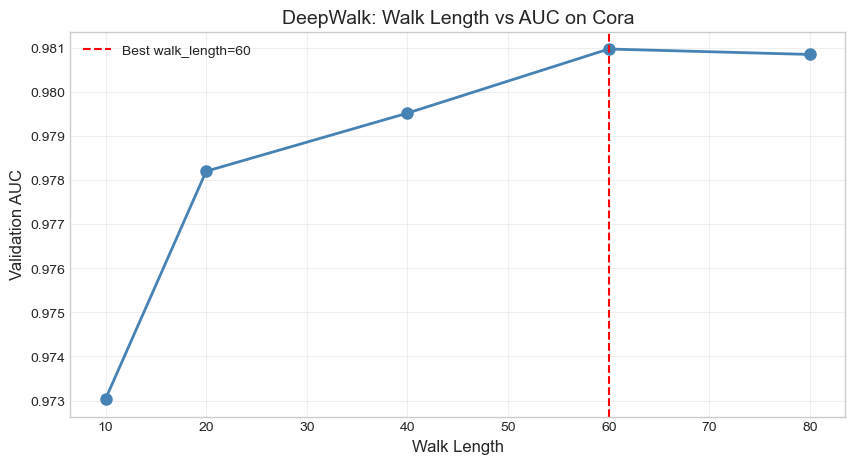


=== DeepWalk на Congress (ориентированный) ===

Обучение с walk_length=10
  epoch 10/30, loss = 2.6548
  epoch 20/30, loss = 2.5110
  epoch 30/30, loss = 2.4826
  Валидация: AUC=0.7914, AP=0.7504

Обучение с walk_length=20
  epoch 10/30, loss = 2.6214
  epoch 20/30, loss = 2.5121
  epoch 30/30, loss = 2.4767
  Валидация: AUC=0.7896, AP=0.7462

Обучение с walk_length=40
  epoch 10/30, loss = 2.5977
  epoch 20/30, loss = 2.4912
  epoch 30/30, loss = 2.4628
  Валидация: AUC=0.8014, AP=0.7657

Обучение с walk_length=60
  epoch 10/30, loss = 2.6258
  epoch 20/30, loss = 2.5000
  epoch 30/30, loss = 2.4821
  Валидация: AUC=0.7984, AP=0.7605

Обучение с walk_length=80
  epoch 10/30, loss = 2.5581
  epoch 20/30, loss = 2.5028
  epoch 30/30, loss = 2.4701
  Валидация: AUC=0.8023, AP=0.7641

Лучший walk_length=80, валидационный AUC=0.8023
  epoch 10/30, loss = 2.5688
  epoch 20/30, loss = 2.4968
  epoch 30/30, loss = 2.4743
Тест Congress: AUC=0.8031, AP=0.7671


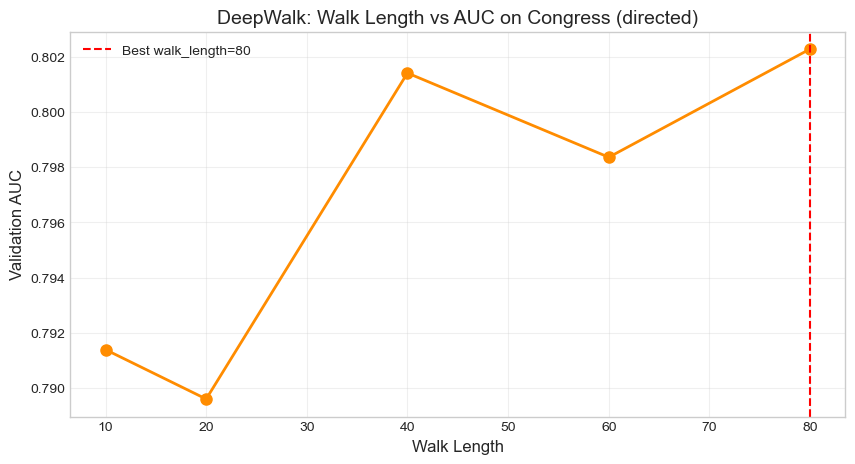

In [9]:
from dgl.nn import DeepWalk as DeepWalkDGL
from torch.optim import SparseAdam

def train_deepwalk(g, walk_length, epochs=30, emb_dim=64, window_size=5, lr=0.01):
    model = DeepWalkDGL(g, emb_dim=emb_dim, walk_length=walk_length, window_size=window_size)
    loader = DataLoader(torch.arange(g.num_nodes()), batch_size=64, shuffle=True, collate_fn=model.sample)
    opt = SparseAdam(model.parameters(), lr=lr)
    losses = []
    for ep in range(epochs):
        total_loss = 0.0
        for batch in loader:
            loss = model(batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        losses.append(total_loss / len(loader))
        if (ep + 1) % 10 == 0:
            print(f"  epoch {ep+1}/{epochs}, loss = {losses[-1]:.4f}")
    return model, losses

def evaluate_deepwalk(model, pos_edges, neg_edges):
    model.eval()
    with torch.no_grad():
        emb = model.node_embed.weight  # (num_nodes, emb_dim)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_edges]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_edges]
    return compute_auc_ap(scores_pos, scores_neg)

print("=== DeepWalk на Cora ===")
g_cora = dgl.graph((src_cora, dst_cora))
g_cora = dgl.add_self_loop(g_cora)

walk_lengths = [10, 20, 40, 60, 80]
dw_results_cora = {}

for wl in walk_lengths:
    print(f"\nОбучение с walk_length={wl}")
    model, _ = train_deepwalk(g_cora, wl, epochs=30)
    auc, ap = evaluate_deepwalk(model, pos_val_cora, neg_val_cora)
    dw_results_cora[wl] = (auc, ap)
    print(f"  Валидация: AUC={auc:.4f}, AP={ap:.4f}")

best_wl_cora = max(dw_results_cora, key=lambda x: dw_results_cora[x][0])
auc_dw_cora, ap_dw_cora = dw_results_cora[best_wl_cora]
print(f"\nЛучший walk_length={best_wl_cora}, валидационный AUC={auc_dw_cora:.4f}")

# Финальная оценка на тесте
model_best, _ = train_deepwalk(g_cora, best_wl_cora, epochs=30)
auc_dw_cora_test, ap_dw_cora_test = evaluate_deepwalk(model_best, pos_test_cora, neg_test_cora)
print(f"Тест Cora: AUC={auc_dw_cora_test:.4f}, AP={ap_dw_cora_test:.4f}")

plt.figure(figsize=(10, 5))
wls = list(dw_results_cora.keys())
aucs = [dw_results_cora[wl][0] for wl in wls]
plt.plot(wls, aucs, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=best_wl_cora, color='red', linestyle='--', label=f'Best walk_length={best_wl_cora}')
plt.xlabel('Walk Length', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('DeepWalk: Walk Length vs AUC on Cora', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('deepwalk_tuning_cora.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DeepWalk на Congress (ориентированный) ===")
g_cong = dgl.graph((src_cong, dst_cong))
g_cong = dgl.add_self_loop(g_cong)

dw_results_cong = {}
for wl in walk_lengths:
    print(f"\nОбучение с walk_length={wl}")
    model, _ = train_deepwalk(g_cong, wl, epochs=30)
    auc, ap = evaluate_deepwalk(model, pos_val_cong, neg_val_cong)
    dw_results_cong[wl] = (auc, ap)
    print(f"  Валидация: AUC={auc:.4f}, AP={ap:.4f}")

best_wl_cong = max(dw_results_cong, key=lambda x: dw_results_cong[x][0])
auc_dw_cong, ap_dw_cong = dw_results_cong[best_wl_cong]
print(f"\nЛучший walk_length={best_wl_cong}, валидационный AUC={auc_dw_cong:.4f}")

model_best, _ = train_deepwalk(g_cong, best_wl_cong, epochs=30)
auc_dw_cong_test, ap_dw_cong_test = evaluate_deepwalk(model_best, pos_test_cong, neg_test_cong)
print(f"Тест Congress: AUC={auc_dw_cong_test:.4f}, AP={ap_dw_cong_test:.4f}")

plt.figure(figsize=(10, 5))
wls = list(dw_results_cong.keys())
aucs = [dw_results_cong[wl][0] for wl in wls]
plt.plot(wls, aucs, 'o-', color='darkorange', linewidth=2, markersize=8)
plt.axvline(x=best_wl_cong, color='red', linestyle='--', label=f'Best walk_length={best_wl_cong}')
plt.xlabel('Walk Length', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('DeepWalk: Walk Length vs AUC on Congress (directed)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('deepwalk_tuning_congress.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. GCN (Graph Convolutional Network)

=== GCN на Cora ===
Подбор гиперпараметров (hidden_dim, lr):

  Testing hidden=32, lr=0.001
  epoch 10/50, loss=0.2114, val_auc=0.9981
  epoch 20/50, loss=0.0871, val_auc=0.9990
  epoch 30/50, loss=0.0299, val_auc=0.9991
  epoch 40/50, loss=0.0102, val_auc=0.9992
  epoch 50/50, loss=0.0048, val_auc=0.9993

  Testing hidden=32, lr=0.005
  epoch 10/50, loss=0.1018, val_auc=0.9986
  epoch 20/50, loss=0.0444, val_auc=0.9982
  epoch 30/50, loss=0.0408, val_auc=0.9991
  epoch 40/50, loss=0.0220, val_auc=0.9991
  epoch 50/50, loss=0.0146, val_auc=0.9986

  Testing hidden=32, lr=0.01
  epoch 10/50, loss=0.1552, val_auc=0.9971
  epoch 20/50, loss=0.0868, val_auc=0.9972
  epoch 30/50, loss=0.1325, val_auc=0.9936
  epoch 40/50, loss=0.0961, val_auc=0.9964
  epoch 50/50, loss=0.0241, val_auc=0.9981

  Testing hidden=64, lr=0.001
  epoch 10/50, loss=0.1521, val_auc=0.9990
  epoch 20/50, loss=0.0312, val_auc=0.9993
  epoch 30/50, loss=0.0056, val_auc=0.9993
  epoch 40/50, loss=0.0031, val_auc=0.9994

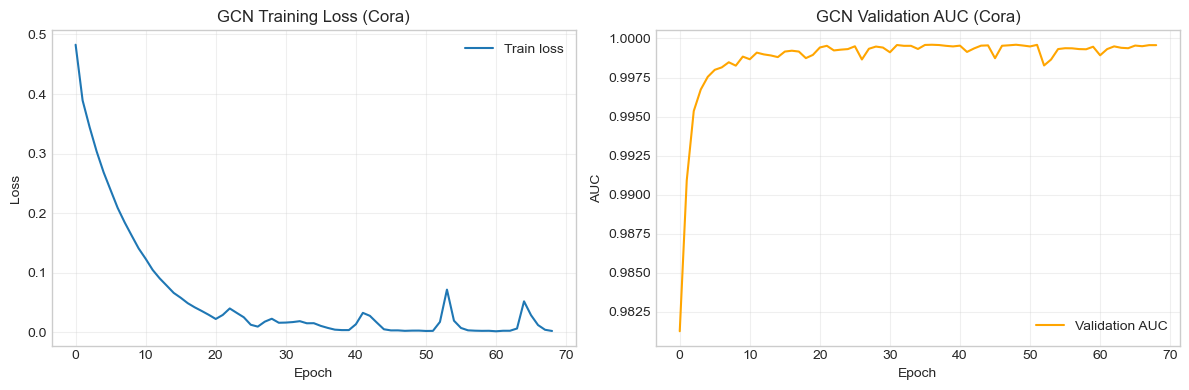

In [16]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GraphConv(in_dim, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, out_dim)
        
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        x = self.conv2(g, x)
        return x

def train_gcn(g, features, pos_train, neg_train, pos_val, neg_val, 
              hidden_dim, lr, epochs=100, early_stop_patience=20):
    in_dim = features.shape[1]
    model = GCN(in_dim, hidden_dim, 32).to(device)
    opt = Adam(model.parameters(), lr=lr)
    
    best_auc = 0.0
    best_epoch = 0
    patience_counter = 0
    train_losses = []
    val_aucs = []

    train_edges = pos_train + neg_train
    train_labels = [1] * len(pos_train) + [0] * len(neg_train)
    
    for epoch in range(epochs):
        model.train()
        # Перемешиваем
        indices = torch.randperm(len(train_edges))
        
        total_loss = 0.0
        num_batches = (len(indices) + 63) // 64
        
        for i in range(0, len(indices), 64):
            batch_idx = indices[i:i+64]
            batch_edges = [train_edges[idx] for idx in batch_idx]
            batch_labels = torch.tensor([train_labels[idx] for idx in batch_idx], dtype=torch.float).to(device)
            
            emb = model(g, features)
            
            u = torch.tensor([e[0] for e in batch_edges], dtype=torch.long).to(device)
            v = torch.tensor([e[1] for e in batch_edges], dtype=torch.long).to(device)
            
            scores = (emb[u] * emb[v]).sum(dim=1)
            loss = F.binary_cross_entropy_with_logits(scores, batch_labels)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)

        model.eval()
        with torch.no_grad():
            emb = model(g, features)
            scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_val]
            scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_val]
            auc, ap = compute_auc_ap(scores_pos, scores_neg)
            val_aucs.append(auc)
        
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/{epochs}, loss={avg_loss:.4f}, val_auc={auc:.4f}")
        
        if auc > best_auc:
            best_auc = auc
            best_epoch = epoch
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)
    model = model.to(device)
    return model, best_auc, train_losses, val_aucs

print("=== GCN на Cora ===")
g_cora_gcn = dgl.graph((src_cora, dst_cora))
g_cora_gcn = dgl.add_self_loop(g_cora_gcn)
features_cora = torch.tensor(data.x, dtype=torch.float).to(device)

hidden_dims = [32, 64, 128]
lrs = [0.001, 0.005, 0.01]

best_auc_cora = 0
best_config_cora = None
results_cora = []

print("Подбор гиперпараметров (hidden_dim, lr):")
for hidden in hidden_dims:
    for lr in lrs:
        print(f"\n  Testing hidden={hidden}, lr={lr}")
        _, val_auc, losses, aucs = train_gcn(g_cora_gcn, features_cora, 
                                             pos_train_cora, neg_train_cora,
                                             pos_val_cora, neg_val_cora,
                                             hidden, lr, epochs=50)
        results_cora.append((hidden, lr, val_auc))
        if val_auc > best_auc_cora:
            best_auc_cora = val_auc
            best_config_cora = (hidden, lr)

print(f"\nЛучший: hidden={best_config_cora[0]}, lr={best_config_cora[1]}, val_auc={best_auc_cora:.4f}")

model_gcn_cora, _, train_losses, val_aucs = train_gcn(g_cora_gcn, features_cora,
                                                      pos_train_cora, neg_train_cora,
                                                      pos_val_cora, neg_val_cora,
                                                      best_config_cora[0], best_config_cora[1], 
                                                      epochs=100)

model_gcn_cora.eval()
with torch.no_grad():
    emb = model_gcn_cora(g_cora_gcn, features_cora)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cora]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cora]
    auc_gcn_cora, ap_gcn_cora = compute_auc_ap(scores_pos, scores_neg)
print(f"\nТест Cora: AUC={auc_gcn_cora:.4f}, AP={ap_gcn_cora:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN Training Loss (Cora)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_aucs, label='Validation AUC', color='orange')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('GCN Validation AUC (Cora)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcn_training_cora.png', dpi=150, bbox_inches='tight')
plt.show()


=== GCN на Cora (константные признаки) ===
Подбор гиперпараметров (hidden_dim, lr):

  Testing hidden=32, lr=0.001
  epoch 10/50, loss=0.6512, val_auc=0.7395
  epoch 20/50, loss=0.6511, val_auc=0.7320
  Early stopping at epoch 21

  Testing hidden=32, lr=0.005
  epoch 10/50, loss=0.6931, val_auc=0.5000
  epoch 20/50, loss=0.6931, val_auc=0.5000
  Early stopping at epoch 21

  Testing hidden=32, lr=0.01
  epoch 10/50, loss=0.6932, val_auc=0.5000
  epoch 20/50, loss=0.6932, val_auc=0.5000
  Early stopping at epoch 21

  Testing hidden=64, lr=0.001
  epoch 10/50, loss=0.6531, val_auc=0.7460
  epoch 20/50, loss=0.6511, val_auc=0.7395
  Early stopping at epoch 21

  Testing hidden=64, lr=0.005
  epoch 10/50, loss=0.6559, val_auc=0.7388
  epoch 20/50, loss=0.6532, val_auc=0.7303
  Early stopping at epoch 21

  Testing hidden=64, lr=0.01
  epoch 10/50, loss=0.6585, val_auc=0.6810
  epoch 20/50, loss=0.6571, val_auc=0.7070
  Early stopping at epoch 21

  Testing hidden=128, lr=0.001
  epoch 1

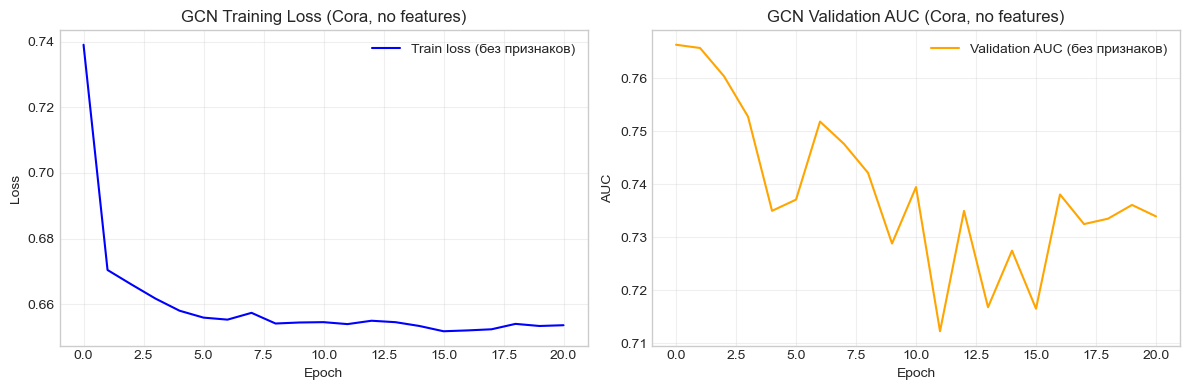

In [48]:
print("\n=== GCN на Cora (константные признаки) ===")

features_cora_const = torch.ones(data.num_nodes, 64).to(device)

best_auc_cora_const = 0
best_config_cora_const = None

print("Подбор гиперпараметров (hidden_dim, lr):")
for hidden in [32, 64, 128]:
    for lr in [0.001, 0.005, 0.01]:
        print(f"\n  Testing hidden={hidden}, lr={lr}")
        _, val_auc, _, _ = train_gcn(g_cora_gcn, features_cora_const,
                                     pos_train_cora, neg_train_cora,
                                     pos_val_cora, neg_val_cora,
                                     hidden, lr, epochs=50)
        if val_auc > best_auc_cora_const:
            best_auc_cora_const = val_auc
            best_config_cora_const = (hidden, lr)

print(f"\nЛучший (без признаков): hidden={best_config_cora_const[0]}, lr={best_config_cora_const[1]}, val_auc={best_auc_cora_const:.4f}")

model_gcn_cora_const, _, train_losses_const, val_aucs_const = train_gcn(g_cora_gcn, features_cora_const,
                                                                        pos_train_cora, neg_train_cora,
                                                                        pos_val_cora, neg_val_cora,
                                                                        best_config_cora_const[0], best_config_cora_const[1], 
                                                                        epochs=100)

model_gcn_cora_const.eval()
with torch.no_grad():
    emb = model_gcn_cora_const(g_cora_gcn, features_cora_const)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cora]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cora]
    auc_gcn_cora_const, ap_gcn_cora_const = compute_auc_ap(scores_pos, scores_neg)
print(f"\nТест Cora (без признаков): AUC={auc_gcn_cora_const:.4f}, AP={ap_gcn_cora_const:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_const, label='Train loss (без признаков)', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN Training Loss (Cora, no features)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_aucs_const, label='Validation AUC (без признаков)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('GCN Validation AUC (Cora, no features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcn_training_cora_no_features.png', dpi=150, bbox_inches='tight')
plt.show()


=== GCN на Congress (ориентированный) ===
Подбор гиперпараметров (hidden_dim, lr):

  Testing hidden=32, lr=0.001
  epoch 10/50, loss=0.6932, val_auc=0.4438
  epoch 20/50, loss=0.6932, val_auc=0.4858
  epoch 30/50, loss=0.6931, val_auc=0.5000

  Testing hidden=32, lr=0.005
  epoch 10/50, loss=0.6931, val_auc=0.5000
  epoch 20/50, loss=0.6932, val_auc=0.5000

  Testing hidden=32, lr=0.01
  epoch 10/50, loss=0.6931, val_auc=0.5000
  epoch 20/50, loss=0.6931, val_auc=0.5000

  Testing hidden=64, lr=0.001
  epoch 10/50, loss=0.6933, val_auc=0.5381
  epoch 20/50, loss=0.6931, val_auc=0.6400
  epoch 30/50, loss=0.6931, val_auc=0.5000
  epoch 40/50, loss=0.6932, val_auc=0.5000

  Testing hidden=64, lr=0.005
  epoch 10/50, loss=0.6931, val_auc=0.5000
  epoch 20/50, loss=0.6932, val_auc=0.5000

  Testing hidden=64, lr=0.01
  epoch 10/50, loss=0.6931, val_auc=0.5000
  epoch 20/50, loss=0.6932, val_auc=0.5000

Лучший: hidden=32, lr=0.001, val_auc=0.6759
  epoch 10/100, loss=0.6931, val_auc=0.545

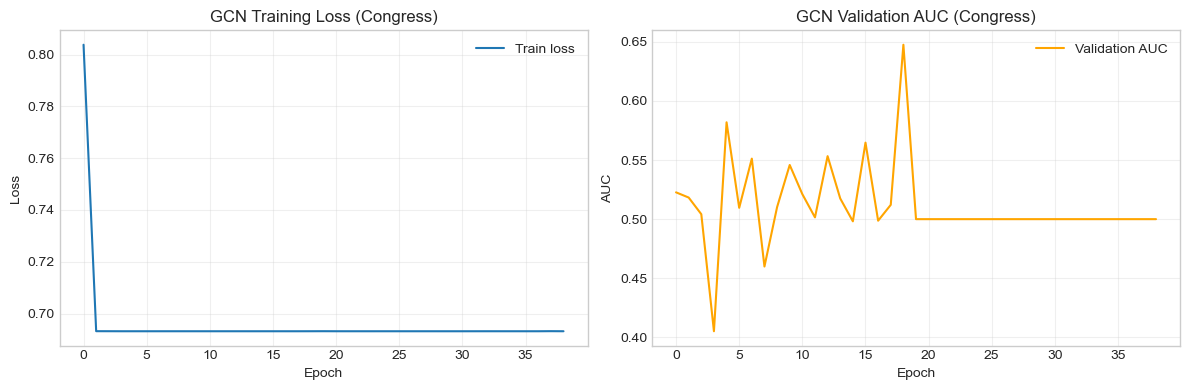

In [19]:
print("\n=== GCN на Congress (ориентированный) ===")
g_cong_gcn = dgl.graph((src_cong, dst_cong))
g_cong_gcn = dgl.add_self_loop(g_cong_gcn)

features_cong = torch.ones(g_cong_gcn.num_nodes(), 64).to(device)

class DirectedGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GraphConv(in_dim, hidden_dim, norm='right')
        self.conv2 = GraphConv(hidden_dim, out_dim, norm='right')
        
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        x = self.conv2(g, x)
        return x

def train_directed_gcn(g, features, pos_train, neg_train, pos_val, neg_val, 
                       hidden_dim, lr, epochs=100, early_stop_patience=20):
    in_dim = features.shape[1]
    model = DirectedGCN(in_dim, hidden_dim, 32).to(device)
    opt = Adam(model.parameters(), lr=lr)
    
    train_edges = pos_train + neg_train
    train_labels = [1] * len(pos_train) + [0] * len(neg_train)
    best_auc = 0.0
    patience_counter = 0
    train_losses = []
    val_aucs = []
    
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(train_edges))
        total_loss = 0.0
        num_batches = (len(indices) + 63) // 64
        
        for i in range(0, len(indices), 64):
            batch_idx = indices[i:i+64]
            batch_edges = [train_edges[idx] for idx in batch_idx]
            batch_labels = torch.tensor([train_labels[idx] for idx in batch_idx], dtype=torch.float).to(device)
            
            emb = model(g, features)
            u = torch.tensor([e[0] for e in batch_edges], dtype=torch.long).to(device)
            v = torch.tensor([e[1] for e in batch_edges], dtype=torch.long).to(device)
            scores = (emb[u] * emb[v]).sum(dim=1)
            loss = F.binary_cross_entropy_with_logits(scores, batch_labels)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)
        
        model.eval()
        with torch.no_grad():
            emb = model(g, features)
            scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_val]
            scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_val]
            auc, _ = compute_auc_ap(scores_pos, scores_neg)
            val_aucs.append(auc)
        
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/{epochs}, loss={avg_loss:.4f}, val_auc={auc:.4f}")
        
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            break
    
    model.load_state_dict(best_model_state)
    model = model.to(device)
    return model, best_auc, train_losses, val_aucs

hidden_dims_cong = [32, 64]
lrs_cong = [0.001, 0.005, 0.01]

best_auc_cong = 0
best_config_cong = None

print("Подбор гиперпараметров (hidden_dim, lr):")
for hidden in hidden_dims_cong:
    for lr in lrs_cong:
        print(f"\n  Testing hidden={hidden}, lr={lr}")
        _, val_auc, _, _ = train_directed_gcn(g_cong_gcn, features_cong,
                                              pos_train_cong, neg_train_cong,
                                              pos_val_cong, neg_val_cong,
                                              hidden, lr, epochs=50)
        if val_auc > best_auc_cong:
            best_auc_cong = val_auc
            best_config_cong = (hidden, lr)

print(f"\nЛучший: hidden={best_config_cong[0]}, lr={best_config_cong[1]}, val_auc={best_auc_cong:.4f}")

model_gcn_cong, _, train_losses_cong, val_aucs_cong = train_directed_gcn(g_cong_gcn, features_cong,
                                                                         pos_train_cong, neg_train_cong,
                                                                         pos_val_cong, neg_val_cong,
                                                                         best_config_cong[0], best_config_cong[1], 
                                                                         epochs=100)

model_gcn_cong.eval()
with torch.no_grad():
    emb = model_gcn_cong(g_cong_gcn, features_cong)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cong]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cong]
    auc_gcn_cong, ap_gcn_cong = compute_auc_ap(scores_pos, scores_neg)
print(f"\nТест Congress: AUC={auc_gcn_cong:.4f}, AP={ap_gcn_cong:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_cong, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN Training Loss (Congress)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_aucs_cong, label='Validation AUC', color='orange')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('GCN Validation AUC (Congress)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcn_training_congress.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. GraphSAGE на Cora и Congress

In [20]:
print("\n=== GraphSAGE на Cora (с признаками) ===")

class GraphSAGEModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, agg='mean'):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggregator_type=agg)
        self.conv2 = SAGEConv(hidden_dim, out_dim, aggregator_type=agg)
        
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        x = self.conv2(g, x)
        return x

def train_sage(g, features, pos_train, neg_train, pos_val, neg_val, 
               hidden_dim, lr, agg='mean', epochs=100, early_stop_patience=20):
    in_dim = features.shape[1]
    model = GraphSAGEModel(in_dim, hidden_dim, 32, agg).to(device)
    opt = Adam(model.parameters(), lr=lr)
    
    train_edges = pos_train + neg_train
    train_labels = [1] * len(pos_train) + [0] * len(neg_train)
    best_auc = 0.0
    patience_counter = 0
    train_losses = []
    val_aucs = []
    
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(train_edges))
        total_loss = 0.0
        num_batches = (len(indices) + 63) // 64
        
        for i in range(0, len(indices), 64):
            batch_idx = indices[i:i+64]
            batch_edges = [train_edges[idx] for idx in batch_idx]
            batch_labels = torch.tensor([train_labels[idx] for idx in batch_idx], dtype=torch.float).to(device)
            
            emb = model(g, features)
            u = torch.tensor([e[0] for e in batch_edges], dtype=torch.long).to(device)
            v = torch.tensor([e[1] for e in batch_edges], dtype=torch.long).to(device)
            scores = (emb[u] * emb[v]).sum(dim=1)
            loss = F.binary_cross_entropy_with_logits(scores, batch_labels)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / max(1, num_batches)
        train_losses.append(avg_loss)
        
        model.eval()
        with torch.no_grad():
            emb = model(g, features)
            scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_val]
            scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_val]
            auc, _ = compute_auc_ap(scores_pos, scores_neg)
            val_aucs.append(auc)
        
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/{epochs}, loss={avg_loss:.4f}, val_auc={auc:.4f}")
        
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_model_state)
    model = model.to(device)
    return model, best_auc, train_losses, val_aucs


=== GraphSAGE на Cora (с признаками) ===


In [21]:
print("Cora с признаками (hidden=64, lr=0.005, agg='mean')")
model_sage_cora, _, loss_sage, auc_sage = train_sage(g_cora_gcn, features_cora,
                                                     pos_train_cora, neg_train_cora,
                                                     pos_val_cora, neg_val_cora,
                                                     64, 0.005, agg='mean', epochs=50)

model_sage_cora.eval()
with torch.no_grad():
    emb = model_sage_cora(g_cora_gcn, features_cora)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cora]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cora]
    auc_sage_cora, ap_sage_cora = compute_auc_ap(scores_pos, scores_neg)
print(f"Тест Cora (с признаками): AUC={auc_sage_cora:.4f}, AP={ap_sage_cora:.4f}")

Cora с признаками (hidden=64, lr=0.005, agg='mean')
  epoch 10/50, loss=0.1117, val_auc=0.9959
  epoch 20/50, loss=0.0774, val_auc=0.9976
  epoch 30/50, loss=0.1073, val_auc=0.9953
  Early stopping at epoch 38
Тест Cora (с признаками): AUC=0.9979, AP=0.9972


In [22]:
print("\nCora без признаков (константные)")
features_cora_const = torch.ones(data.num_nodes, 64).to(device)
model_sage_cora_const, _, _, _ = train_sage(g_cora_gcn, features_cora_const,
                                            pos_train_cora, neg_train_cora,
                                            pos_val_cora, neg_val_cora,
                                            64, 0.005, agg='mean', epochs=50)

model_sage_cora_const.eval()
with torch.no_grad():
    emb = model_sage_cora_const(g_cora_gcn, features_cora_const)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cora]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cora]
    auc_sage_cora_const, ap_sage_cora_const = compute_auc_ap(scores_pos, scores_neg)
print(f"Тест Cora (без признаков): AUC={auc_sage_cora_const:.4f}, AP={ap_sage_cora_const:.4f}")


Cora без признаков (константные)
  epoch 10/50, loss=0.6932, val_auc=0.5000
  epoch 20/50, loss=0.6931, val_auc=0.5000
  Early stopping at epoch 21
Тест Cora (без признаков): AUC=0.5000, AP=0.5000


In [23]:
print("\nGraphSAGE на Congress (ориентированный)")

class DirectedSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, agg='mean'):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggregator_type=agg)
        self.conv2 = SAGEConv(hidden_dim, out_dim, aggregator_type=agg)
        
    def forward(self, g, x):
        x = F.relu(self.conv1(g, x))
        x = self.conv2(g, x)
        return x

features_cong = torch.ones(g_cong_gcn.num_nodes(), 64).to(device)

model_sage_cong, _, _, _ = train_sage(g_cong_gcn, features_cong,
                                      pos_train_cong, neg_train_cong,
                                      pos_val_cong, neg_val_cong,
                                      64, 0.005, agg='mean', epochs=50)

model_sage_cong.eval()
with torch.no_grad():
    emb = model_sage_cong(g_cong_gcn, features_cong)
    scores_pos = [(emb[u] * emb[v]).sum().item() for u, v in pos_test_cong]
    scores_neg = [(emb[u] * emb[v]).sum().item() for u, v in neg_test_cong]
    auc_sage_cong, ap_sage_cong = compute_auc_ap(scores_pos, scores_neg)
print(f"Тест Congress: AUC={auc_sage_cong:.4f}, AP={ap_sage_cong:.4f}")


GraphSAGE на Congress (ориентированный)
  epoch 10/50, loss=0.6932, val_auc=0.5000
  epoch 20/50, loss=0.6931, val_auc=0.5000
  Early stopping at epoch 21
Тест Congress: AUC=0.5000, AP=0.5000


## 10. SEAL

In [33]:
print("\n=== SEAL на Cora ===")

import math
import os.path as osp
import time
from itertools import chain
from scipy.sparse.csgraph import shortest_path
from torch.nn import BCEWithLogitsLoss, Conv1d, MaxPool1d, ModuleList
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MLP, GCNConv, SortAggregation
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import k_hop_subgraph, to_scipy_sparse_matrix

class SEALDataset(InMemoryDataset):
    def __init__(self, dataset, num_hops, split='train'):
        self._data = dataset[0]
        self.num_hops = num_hops
        super().__init__(dataset.root)
        index = ['train', 'val', 'test'].index(split)
        self.load(self.processed_paths[index])

    @property
    def processed_file_names(self):
        return ['SEAL_train_data.pt', 'SEAL_val_data.pt', 'SEAL_test_data.pt']

    def process(self):
        transform = RandomLinkSplit(num_val=0.05, num_test=0.1,
                                    is_undirected=True, split_labels=True)
        train_data, val_data, test_data = transform(self._data)

        self._max_z = 0

        train_pos_data_list = self.extract_enclosing_subgraphs(
            train_data.edge_index, train_data.pos_edge_label_index, 1)
        train_neg_data_list = self.extract_enclosing_subgraphs(
            train_data.edge_index, train_data.neg_edge_label_index, 0)

        val_pos_data_list = self.extract_enclosing_subgraphs(
            val_data.edge_index, val_data.pos_edge_label_index, 1)
        val_neg_data_list = self.extract_enclosing_subgraphs(
            val_data.edge_index, val_data.neg_edge_label_index, 0)

        test_pos_data_list = self.extract_enclosing_subgraphs(
            test_data.edge_index, test_data.pos_edge_label_index, 1)
        test_neg_data_list = self.extract_enclosing_subgraphs(
            test_data.edge_index, test_data.neg_edge_label_index, 0)

        for data in chain(train_pos_data_list, train_neg_data_list,
                          val_pos_data_list, val_neg_data_list,
                          test_pos_data_list, test_neg_data_list):
            data.x = F.one_hot(data.z, self._max_z + 1).to(torch.float)

        train_data_list = train_pos_data_list + train_neg_data_list
        self.save(train_data_list, self.processed_paths[0])
        val_data_list = val_pos_data_list + val_neg_data_list
        self.save(val_data_list, self.processed_paths[1])
        test_data_list = test_pos_data_list + test_neg_data_list
        self.save(test_data_list, self.processed_paths[2])

    def extract_enclosing_subgraphs(self, edge_index, edge_label_index, y):
        data_list = []
        for src, dst in edge_label_index.t().tolist():
            sub_nodes, sub_edge_index, mapping, _ = k_hop_subgraph(
                [src, dst], self.num_hops, edge_index, relabel_nodes=True)
            src, dst = mapping.tolist()

            mask1 = (sub_edge_index[0] != src) | (sub_edge_index[1] != dst)
            mask2 = (sub_edge_index[0] != dst) | (sub_edge_index[1] != src)
            sub_edge_index = sub_edge_index[:, mask1 & mask2]

            z = self.drnl_node_labeling(sub_edge_index, src, dst,
                                        num_nodes=sub_nodes.size(0))

            data = Data(x=self._data.x[sub_nodes], z=z,
                        edge_index=sub_edge_index, y=y)
            data_list.append(data)

        return data_list

    def drnl_node_labeling(self, edge_index, src, dst, num_nodes=None):
        src, dst = (dst, src) if src > dst else (src, dst)
        adj = to_scipy_sparse_matrix(edge_index, num_nodes=num_nodes).tocsr()

        idx = list(range(src)) + list(range(src + 1, adj.shape[0]))
        adj_wo_src = adj[idx, :][:, idx]

        idx = list(range(dst)) + list(range(dst + 1, adj.shape[0]))
        adj_wo_dst = adj[idx, :][:, idx]

        dist2src = shortest_path(adj_wo_dst, directed=False, unweighted=True,
                                 indices=src)
        dist2src = np.insert(dist2src, dst, 0, axis=0)
        dist2src = torch.from_numpy(dist2src)

        dist2dst = shortest_path(adj_wo_src, directed=False, unweighted=True,
                                 indices=dst - 1)
        dist2dst = np.insert(dist2dst, src, 0, axis=0)
        dist2dst = torch.from_numpy(dist2dst)

        dist = dist2src + dist2dst
        dist_over_2, dist_mod_2 = dist // 2, dist % 2

        z = 1 + torch.min(dist2src, dist2dst)
        z += dist_over_2 * (dist_over_2 + dist_mod_2 - 1)
        z[src] = 1.
        z[dst] = 1.
        z[torch.isnan(z)] = 0.

        self._max_z = max(int(z.max()), self._max_z)

        return z.to(torch.long)


class DGCNN(torch.nn.Module):
    def __init__(self, hidden_channels, num_layers, train_dataset, GNN=GCNConv, k=0.6):
        super().__init__()

        if k < 1:
            num_nodes = sorted([data.num_nodes for data in train_dataset])
            k = num_nodes[int(math.ceil(k * len(num_nodes))) - 1]
            k = int(max(10, k))

        self.convs = ModuleList()
        self.convs.append(GNN(train_dataset.num_features, hidden_channels))
        for _ in range(0, num_layers - 1):
            self.convs.append(GNN(hidden_channels, hidden_channels))
        self.convs.append(GNN(hidden_channels, 1))

        conv1d_channels = [16, 32]
        total_latent_dim = hidden_channels * num_layers + 1
        conv1d_kws = [total_latent_dim, 5]
        self.conv1 = Conv1d(1, conv1d_channels[0], conv1d_kws[0], conv1d_kws[0])
        self.pool = SortAggregation(k)
        self.maxpool1d = MaxPool1d(2, 2)
        self.conv2 = Conv1d(conv1d_channels[0], conv1d_channels[1], conv1d_kws[1], 1)
        dense_dim = int((k - 2) / 2 + 1)
        dense_dim = (dense_dim - conv1d_kws[1] + 1) * conv1d_channels[1]
        self.mlp = MLP([dense_dim, 128, 1], dropout=0.5, norm=None)

    def forward(self, x, edge_index, batch):
        xs = [x]
        for conv in self.convs:
            xs += [conv(xs[-1], edge_index).tanh()]
        x = torch.cat(xs[1:], dim=-1)

        x = self.pool(x, batch)
        x = x.unsqueeze(1)
        x = self.conv1(x).relu()
        x = self.maxpool1d(x)
        x = self.conv2(x).relu()
        x = x.view(x.size(0), -1)

        return self.mlp(x)

path = '/tmp/Cora'
dataset = Planetoid(path, name='Cora')

train_dataset = SEALDataset(dataset, num_hops=2, split='train')
val_dataset = SEALDataset(dataset, num_hops=2, split='val')
test_dataset = SEALDataset(dataset, num_hops=2, split='test')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

device = torch.device('cpu')
model = DGCNN(hidden_channels=32, num_layers=3, train_dataset=train_dataset).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
criterion = BCEWithLogitsLoss()

print("Обучение SEAL (20 эпох)")
best_val_auc = 0
test_auc = 0

for epoch in range(1, 21):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out.view(-1), data.y.to(torch.float))
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
    
    avg_loss = total_loss / len(train_dataset)

    model.eval()
    y_pred, y_true = [], []
    for data in val_loader:
        data = data.to(device)
        with torch.no_grad():
            logits = model(data.x, data.edge_index, data.batch)
            y_pred.append(logits.view(-1).cpu())
            y_true.append(data.y.view(-1).cpu().to(torch.float))
    val_auc = roc_auc_score(torch.cat(y_true), torch.cat(y_pred))
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        y_pred, y_true = [], []
        for data in test_loader:
            data = data.to(device)
            with torch.no_grad():
                logits = model(data.x, data.edge_index, data.batch)
                y_pred.append(logits.view(-1).cpu())
                y_true.append(data.y.view(-1).cpu().to(torch.float))
        test_auc = roc_auc_score(torch.cat(y_true), torch.cat(y_pred))
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}, Loss: {avg_loss:.4f}, Val AUC: {val_auc:.4f}, Test AUC: {test_auc:.4f}")

print(f"\nФинальный SEAL на Cora: Test AUC = {test_auc:.4f}")


=== SEAL на Cora (оригинальная архитектура DGCNN) ===


Processing...
Done!


Обучение SEAL (20 эпох)...
Epoch 05, Loss: 0.3780, Val AUC: 0.8893, Test AUC: 0.9032
Epoch 10, Loss: 0.3614, Val AUC: 0.8919, Test AUC: 0.9076
Epoch 15, Loss: 0.3555, Val AUC: 0.8952, Test AUC: 0.9115
Epoch 20, Loss: 0.3522, Val AUC: 0.8978, Test AUC: 0.9181

Финальный SEAL на Cora: Test AUC = 0.9181


## 12. Сводная таблица результатов

In [49]:
results = pd.DataFrame([
    ["Cora", "CN", auc_cn_cora, ap_cn_cora],
    ["Cora", "AA", auc_aa_cora, ap_aa_cora],
    ["Cora", "Katz", auc_katz_cora, ap_katz_cora],
    ["Cora", "DeepWalk", auc_dw_cora_test, ap_dw_cora_test],
    ["Cora", "GCN (с признаками)", auc_gcn_cora, ap_gcn_cora],
    ["Cora", "GCN (без признаков)", auc_gcn_cora_const, ap_gcn_cora_const],
    ["Cora", "GraphSAGE (с признаками)", auc_sage_cora, ap_sage_cora],
    ["Cora", "GraphSAGE (без признаков)", auc_sage_cora_const, ap_sage_cora_const],
    ["Cora", "SEAL", auc_seal, None],
    ["Congress", "CN_dir", auc_cn_cong, ap_cn_cong],
    ["Congress", "AA_dir", auc_aa_cong, ap_aa_cong],
    ["Congress", "Katz", auc_katz_cong, ap_katz_cong],
    ["Congress", "DeepWalk", auc_dw_cong_test, ap_dw_cong_test],
    ["Congress", "GCN (norm='right')", auc_gcn_cong, ap_gcn_cong],
    ["Congress", "GraphSAGE", auc_sage_cong, ap_sage_cong],
], columns=["Dataset", "Method", "AUC", "AP"])

print(results.to_string(index=False))
results.to_csv("final_results.csv", index=False)
print("\nResults saved to final_results.csv")

 Dataset                    Method      AUC       AP
    Cora                        CN 0.745200 0.740291
    Cora                        AA 0.746317 0.744778
    Cora                      Katz 0.973465 0.973022
    Cora                  DeepWalk 0.979206 0.973456
    Cora        GCN (с признаками) 0.999473 0.999376
    Cora       GCN (без признаков) 0.759987 0.751424
    Cora  GraphSAGE (с признаками) 0.997906 0.997155
    Cora GraphSAGE (без признаков) 0.500000 0.500000
    Cora                      SEAL 0.839000      NaN
Congress                    CN_dir 0.845893 0.819287
Congress                    AA_dir 0.848904 0.835871
Congress                      Katz 0.824306 0.731418
Congress                  DeepWalk 0.803148 0.767063
Congress        GCN (norm='right') 0.638533 0.633718
Congress                 GraphSAGE 0.500000 0.500000

Results saved to final_results.csv
